In [1]:
import numpy as np
import pandas as pd
from ISLP.models import ModelSpec as MS , summarize
import statsmodels.api as sm
from ISLP import load_data
from matplotlib.pyplot import subplots
from numpy.ma.core import argmax
from sympy.printing.pretty.pretty_symbology import line_width

In [2]:
auto = load_data("Auto")

In [3]:
auto.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [4]:
design = MS(["horsepower"])
X = design.fit_transform(auto)
y = auto["mpg"]

In [5]:
X

,intercept,horsepower
name,,
chevrolet chevelle malibu,1.0,130
buick skylark 320,1.0,165
plymouth satellite,1.0,150
amc rebel sst,1.0,150
ford torino,1.0,140
...,...,...
ford mustang gl,1.0,86
vw pickup,1.0,52
dodge rampage,1.0,84


In [6]:
model = sm.OLS(y,X)
results = model.fit()

In [7]:
summarize(results)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [8]:
results.params

intercept     39.935861
horsepower    -0.157845
dtype: float64

C:\Users\AAYUSH OJHA\AppData\Local\Temp\ipykernel_20312\609781908.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[1], results.params[0], "r--")


<Figure size 1000x800 with 0 Axes>

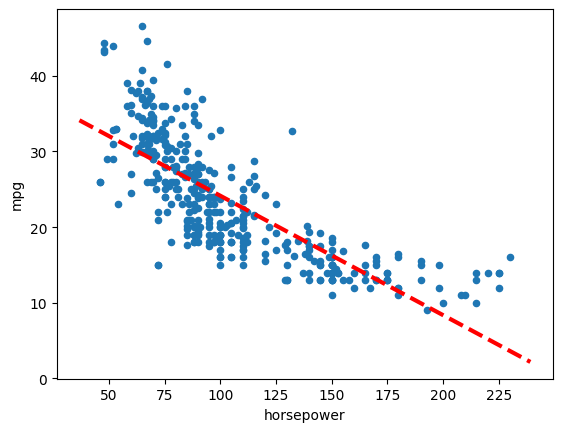

In [9]:
import matplotlib.pyplot as plt

def abline(ax,m,c, *args):
    x_lim = ax.get_xlim()
    y_lim = [c+(m*x_lim[0]), c+(m*x_lim[1])]
    ax.plot(x_lim, y_lim, *args, linewidth=3)

plt.figure(figsize=(10,8))
ax = auto.plot.scatter(y="mpg", x="horsepower")
abline(ax, results.params[1], results.params[0], "r--")

In [10]:
new_df = pd.DataFrame({"horsepower": [98, 65, 36]})
predicting_X = design.transform(new_df)
predicted_values = results.get_prediction(predicting_X)

In [11]:
predicted_values.predicted_mean

array([24.46707715, 29.67595335, 34.25345062])

In [12]:
predicted_values.conf_int(alpha=0.05)

array([[23.97307896, 24.96107534],
       [28.97775556, 30.37415114],
       [33.25838674, 35.2485145 ]])

In [13]:
predicted_values.conf_int(obs=True, alpha=0.05)

array([[14.80939607, 34.12475823],
       [20.00567674, 39.34622997],
       [24.55721827, 43.94968297]])

## Residual Plot

Text(0, 0.5, 'Residual')

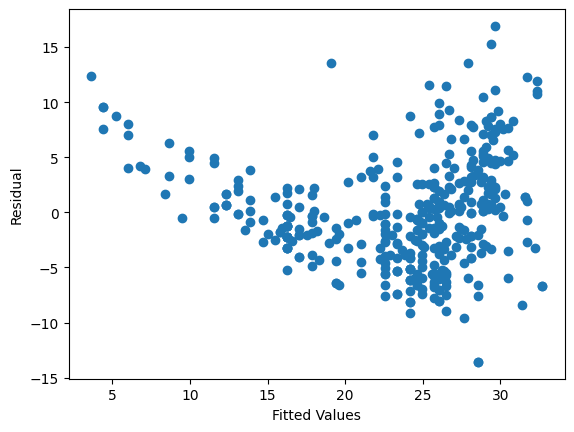

In [27]:
plt.scatter(y=results.resid, x = results.fittedvalues)
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
# errors variance are not constant

## Removing the heteroscedasticity

In [29]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [35]:
y1 = np.log(auto["mpg"])

In [36]:
model1 = sm.OLS(y1, X)
results1 = model1.fit()

Text(0, 0.5, 'Residual')

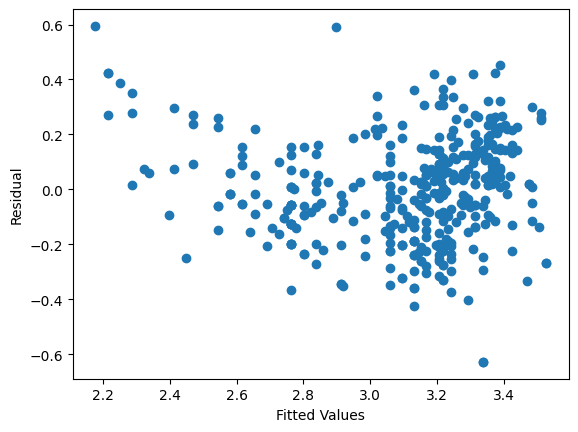

In [37]:
plt.scatter(y=results1.resid, x = results1.fittedvalues)
plt.xlabel("Fitted Values")
plt.ylabel("Residual")

In [38]:
summarize(results1)

,coef,std err,t,P>|t|
intercept,3.8645,0.028,139.194,0.0
horsepower,-0.0073,0.000,-29.405,0.0


In [48]:
auto["log_mpg"] = np.log(auto["mpg"])

C:\Users\AAYUSH OJHA\AppData\Local\Temp\ipykernel_20312\465414754.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax1, results1.params[1], results1.params[0], "r--")


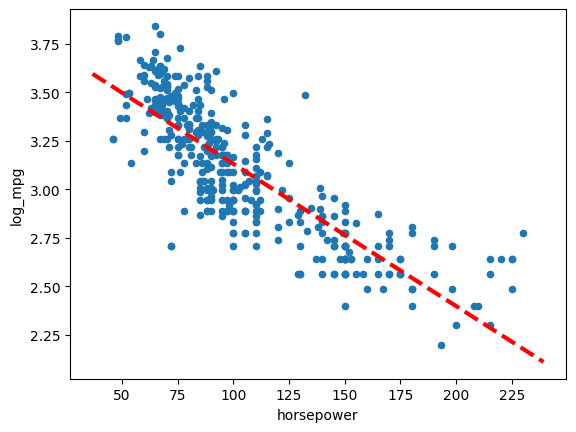

In [51]:
ax1 = auto.plot.scatter(x = "horsepower", y = "log_mpg")
abline(ax1, results1.params[1], results1.params[0], "r--")

## Leverage Plot

np.int64(115)

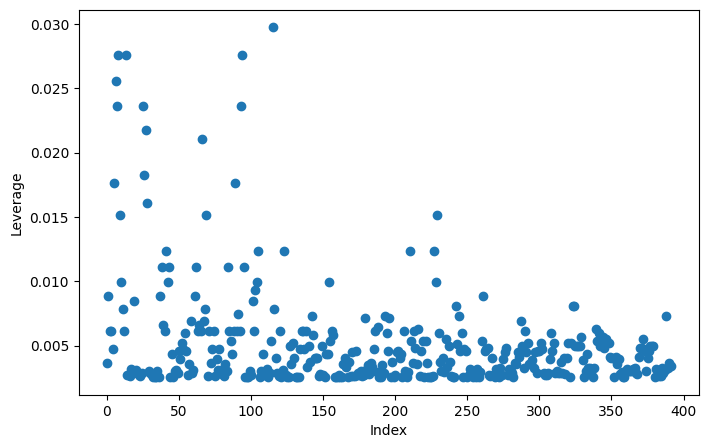

In [58]:
inf = results.get_influence()
ax2 = plt.subplots(figsize=(8,5))[1]
ax2.scatter(x=np.arange(X.shape[0]), y=inf.hat_matrix_diag)
ax2.set_xlabel("Index")
ax2.set_ylabel("Leverage")
np.argmax(inf.hat_matrix_diag)

## Studentised Residuals

np.int64(115)

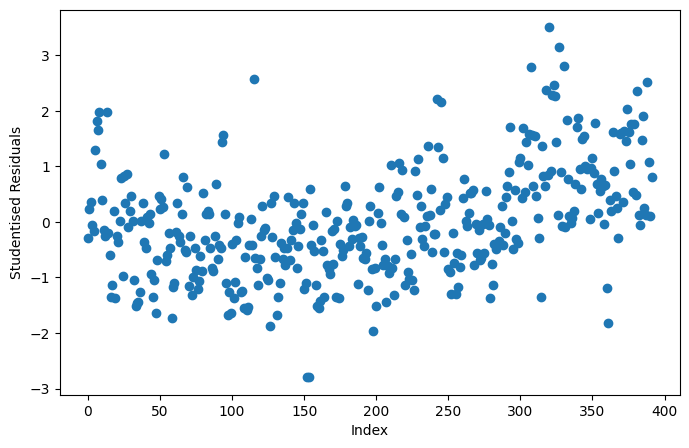

In [63]:
inf = results.get_influence()
ax2 = plt.subplots(figsize=(8,5))[1]
ax2.scatter(x=np.arange(X.shape[0]), y=inf.resid_studentized_external)
ax2.set_xlabel("Index")
ax2.set_ylabel("Studentised Residuals")
np.argmax(inf.hat_matrix_diag)

## Finding the most Influential Points

In [62]:
cooks_d = inf.cooks_distance[0]
print("Top 5 influential points (Cook's D):")
print(np.argsort(cooks_d)[::-1][:5])

Top 5 influential points (Cook's D):
[115  13   8   6  94]


Cook's D for index 115: 0.1004507336393454
Threshold (4/n): 0.01020408163265306


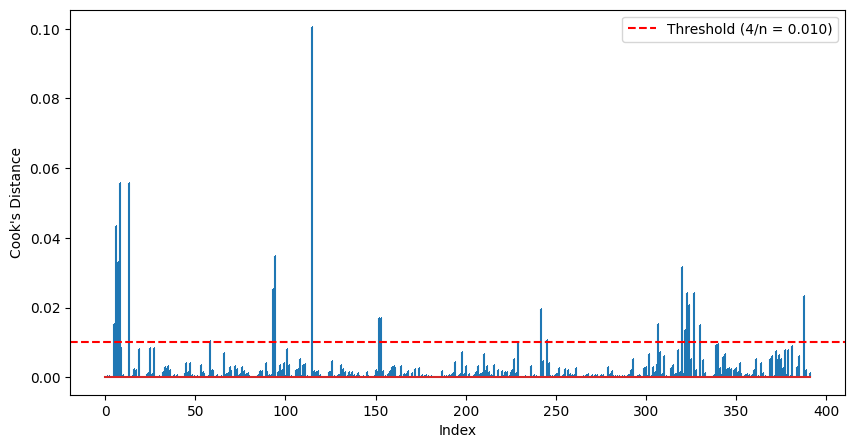

In [69]:
# Check exact Cook's distance for index 115
print("Cook's D for index 115:", cooks_d[115])

# Threshold rule of thumb: 4 / n
threshold = 4 / len(auto)
print("Threshold (4/n):", threshold)

# Plot Cook's Distance across all points
plt.figure(figsize=(10, 5))
plt.stem(cooks_d, markerfmt=",")
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (4/n = {threshold:.3f})')
plt.xlabel("Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.show()